In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
anime_data_path = 'data/anime_processed.parquet'
anime_df = pd.read_parquet(anime_data_path)
anime_df.head(1)

,mal_id,title_english,type,source,episodes,duration,rating,score,scored_by,rank,popularity,members,favorites,year,demographics,studios,genres,themes
0,1,Cowboy Bebop,TV,Original,26,24,R - 17+ (violence & profanity),8.75,1062212,49,41,2057323,89639,1998,[],[Sunrise],"[Action, Award Winning, Sci-Fi]","[Adult Cast, Space]"


In [4]:
# drop nan values
cols_to_check = anime_df.columns.difference(["rank", "episodes"])
anime_df = anime_df.dropna(subset=cols_to_check)


# Basic exploratory analysis

In [5]:
# =========================
# BASIC EXPLORATORY ANALYSIS
# =========================

# 1. Find the top 20 highest-rated anime.
# anime_df.sort_values('score', axis=1)['title_english']

res_1 = (anime_df
 .sort_values('score', inplace=False, ascending=False)
 .head(20)[['title_english', 'score']]
 )

# res_1


In [6]:

# 2. Find the most popular anime by:
#    - members
#    - favorites
#    - popularity rank

def most_by(df: pd.DataFrame, key, n=5):
    return (
        df
        .sort_values(key, ascending=False)
        .head(n)[['title_english', key]]
    )


by_members = most_by(anime_df, 'members')
by_favorites = most_by(anime_df, 'favorites')
by_popularity = (
    anime_df
    .copy()
    .sort_values('popularity', ascending=True)
    .head()[['title_english', 'popularity']]
)


count    4972.000000
mean        6.652120
std         0.854627
min         1.890000
25%         6.137500
50%         6.760000
75%         7.250000
max         9.110000
Name: score, dtype: float64


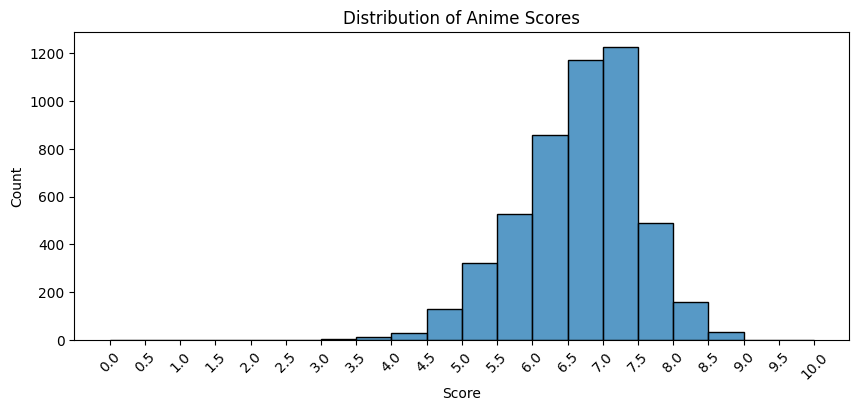

In [7]:

# 3. Analyze score distribution:
#    - mean
#    - median
#    - standard deviation
#    - histogram
print(anime_df['score'].describe())

scores = anime_df['score']
bins = np.arange(0, 10.5, 0.5)

plt.figure(figsize=(10, 4))

# sns.histplot(scores, bins=bins, kde=True)
sns.histplot(scores, bins=bins, kde=False)

plt.title("Distribution of Anime Scores")
plt.xlabel("Score")
plt.ylabel("Count")

plt.xticks(bins, rotation=45)

plt.show()

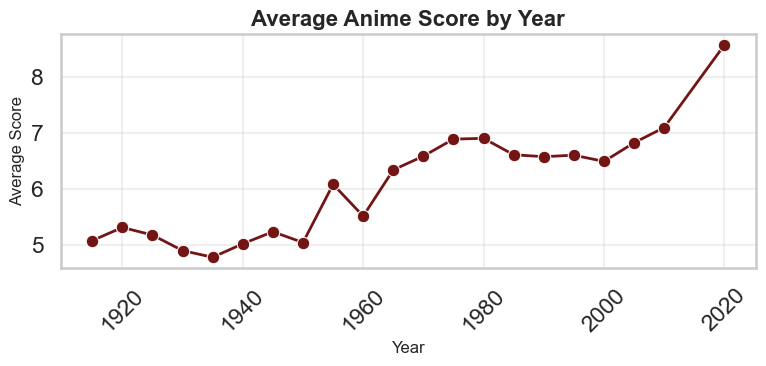

In [8]:
# 4. Analyze anime production by year.

years = anime_df['year']

# average scores by years (bins of 5)
anime_score_year = anime_df[['year', 'score']]
years_binned = pd.Series(years) // 5 * 5
anime_scores_binned = pd.concat((years_binned, anime_df['score']), axis=1)

# in 2020th no anime bcz didnt parse data enough yet
# sns.histplot(years, bins=np.arange(years.min(), years.max(), 5))


avg_score_by_years = (
    anime_scores_binned
    .groupby('year')
    .mean()
)

sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=avg_score_by_years,
    x="year",
    y="score",
    marker="o",
    linewidth=2,
    color="#731515"
)

plt.title("Average Anime Score by Year", fontsize=16, weight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Score", fontsize=12)

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# anime_scores_binned

# Results:
# there's a growing trend in number of animes (more animes each year)
# can see average score growth as year proceeds (does this mean that with time anime got better?)



In [9]:
# 5. Find the most common anime types:
#    TV, Movie, OVA, ONA, Special, etc.
(
    anime_df
    .groupby('type')['type']
    .count()
)


type
CM               3
Movie          832
Music           42
ONA             65
OVA           1711
PV               1
Special        319
TV            1860
TV Special     139
Name: type, dtype: int64

In [20]:
# 6. Find the most common source materials:
#    Manga, Original, Light Novel, Game, etc.
(
    anime_df
    .groupby('source')['source']
    .count()
    .sort_values(ascending=False)
)

source
Manga           1822
Original        1294
Visual novel     574
Unknown          354
Game             223
Light novel      204
Novel            197
Other            158
Book              51
4-koma manga      42
Picture book      23
Card game         10
Mixed media        8
Music              5
Web manga          4
Radio              3
Name: source, dtype: int64

1 1787


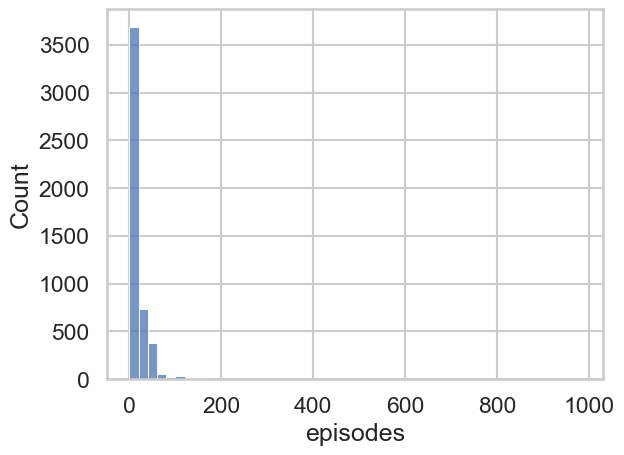

In [ ]:
# 7. Analyze episode count distribution.
ep_min = anime_df['episodes'].min()
ep_max = anime_df['episodes'].max()
sns.histplot(anime_df['episodes'], bins=np.arange(ep_min, 1000, 20))



<Axes: xlabel='duration', ylabel='Count'>

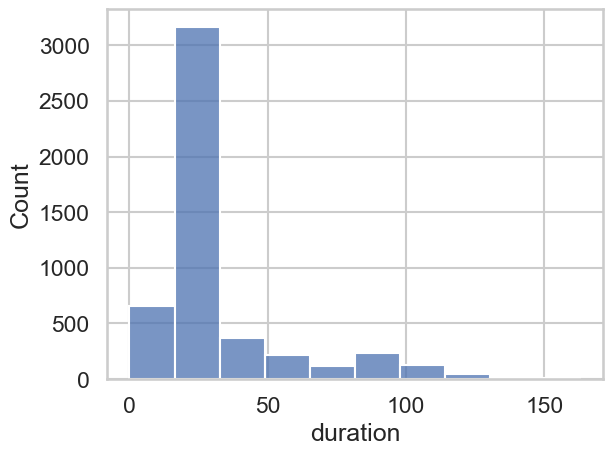

In [ ]:
# 8. Analyze duration distribution.
duration = anime_df['duration']
sns.histplot(duration, bins=10)


In [ ]:
# 9. Find anime with:
#    - highest score
hi_score = (
    anime_df
    .sort_values('score', ascending=False)[['title_english', 'score']]
    .iloc[0]
    .to_list()
)
print('Highest score: ', hi_score, sep='\n')

#    - lowest score
lo_score = (
    anime_df
    .sort_values('score', ascending=True)[['title_english', 'score']]
    .iloc[0]
    .to_list()
)
print('Lowest score: ', lo_score, sep='\n')

#    - most favorites
most_fav = (
    anime_df
    .sort_values('favorites', ascending=False)[['title_english', 'favorites']]
    .iloc[0]
    .to_list()
)
print('Most favorites: ', most_fav, sep='\n')

#    - most members
most_members = (
    anime_df
    .sort_values('members', ascending=False)[['title_english', 'members']]
    .iloc[0]
    .to_list()
)
print('Most members: ', most_members, sep='\n')


Highest score: 
['Fullmetal Alchemist: Brotherhood', np.float64(9.11)]
Lowest score: 
['Skelter Heaven', np.float64(1.89)]
Most favorites: 
['One Piece', np.int64(252104)]
Most members: 
['Death Note', np.int64(4300530)]


In [58]:
# =========================
# GENRES / THEMES / DEMOGRAPHICS
# =========================

# problem: anime can have more than 1 genre
# how to split anime by genres? so that we have many anime rows that contain those genres
# 

# 10. Find the most common genres.
from collections import Counter

genres = anime_df['genres']  # remove
all_genres_list = (
    genres
    .apply(list)
    .sum()  # gor list of all genres concatenated
)
genre_counts = Counter(all_genres_list)
print(genre_counts)

# 11. Find the highest-rated genres.

# 12. Find the most popular genres.

# 13. Analyze genre trends over time.

# 14. Find the most common themes.

# 15. Compare score distributions between demographics:
#     Shounen, Seinen, Shoujo, Josei, etc.

# 16. Analyze which demographics are most popular.


Counter({'Comedy': 1728, 'Adventure': 1350, 'Sci-Fi': 1333, 'Action': 1173, 'Drama': 1082, 'Fantasy': 999, 'Romance': 803, 'Hentai': 681, 'Supernatural': 393, 'Mystery': 312, 'Ecchi': 310, 'Horror': 200, 'Sports': 185, 'Award Winning': 123, 'Suspense': 105, 'Slice of Life': 91, 'Boys Love': 61, 'Avant Garde': 55, 'Girls Love': 42, 'Erotica': 22, 'Gourmet': 20})


In [13]:

# =========================
# STUDIO ANALYSIS
# =========================

# 17. Find the most productive studios.

# 18. Find studios with highest average scores.

# 19. Find studios with highest average popularity.

# 20. Analyze relationship between:
#     studio productivity vs average score.

# 21. Find studios specializing in certain genres.


In [ ]:

# =========================
# RELATIONSHIPS / CORRELATIONS
# =========================

# 22. Analyze correlation between:
#     score and popularity.

# 23. Analyze correlation between:
#     score and members.

# 24. Analyze correlation between:
#     favorites and score.

# 25. Analyze correlation between:
#     duration and score.

# 26. Analyze correlation between:
#     episode count and popularity.



In [15]:

# =========================
# ADVANCED ANALYSIS
# =========================

# 27. Find underrated anime:
#     high score + low popularity.

# 28. Find overrated anime:
#     low score + very high popularity.

# 29. Analyze how anime scores changed over years.

# 30. Analyze whether Originals or Adaptations score higher.

# 31. Compare Movies vs TV series:
#     score, popularity, favorites, duration.

# 32. Find the most genre-diverse studios.

# 33. Analyze multi-genre anime:
#     do more genres correlate with popularity or score?

# 34. Analyze long-running anime separately.

# 35. Build a studio collaboration network.

# 36. Find niche genres with highest average scores.

# 37. Analyze trends in anime demographics over time.

# 38. Identify outliers in:
#     score, popularity, duration, episodes.

# 39. Compare old anime vs modern anime.

# 40. Build a simple recommendation similarity metric.
